In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv(r"C:\Users\H P\Downloads\archive (73)\retail_store_inventory.csv")
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring


In [3]:
df.shape

(73100, 15)

In [4]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')

In [5]:
df.columns = (df.columns.str.lower()
                         .str.strip()
                         .str.replace(" ", "_"))

In [6]:
df.columns

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'demand_forecast',
       'price', 'discount', 'weather_condition', 'holiday/promotion',
       'competitor_pricing', 'seasonality'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                73100 non-null  object 
 1   store_id            73100 non-null  object 
 2   product_id          73100 non-null  object 
 3   category            73100 non-null  object 
 4   region              73100 non-null  object 
 5   inventory_level     73100 non-null  int64  
 6   units_sold          73100 non-null  int64  
 7   units_ordered       73100 non-null  int64  
 8   demand_forecast     73100 non-null  float64
 9   price               73100 non-null  float64
 10  discount            73100 non-null  int64  
 11  weather_condition   73100 non-null  object 
 12  holiday/promotion   73100 non-null  int64  
 13  competitor_pricing  73100 non-null  float64
 14  seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [8]:
df.describe()

,inventory_level,units_sold,units_ordered,demand_forecast,price,discount,holiday/promotion,competitor_pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [9]:
df.isnull().sum()

date                  0
store_id              0
product_id            0
category              0
region                0
inventory_level       0
units_sold            0
units_ordered         0
demand_forecast       0
price                 0
discount              0
weather_condition     0
holiday/promotion     0
competitor_pricing    0
seasonality           0
dtype: int64

COPY ORIGINAL DATA

In [10]:
df1 = df.copy()

In [11]:
df1

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,demand_forecast,price,discount,weather_condition,holiday/promotion,competitor_pricing,seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring


In [12]:
df1.dtypes

date                   object
store_id               object
product_id             object
category               object
region                 object
inventory_level         int64
units_sold              int64
units_ordered           int64
demand_forecast       float64
price                 float64
discount                int64
weather_condition      object
holiday/promotion       int64
competitor_pricing    float64
seasonality            object
dtype: object

CHANGE DATA TYPES

In [13]:
df1["date"] = pd.to_datetime(df1["date"])

In [14]:
df1[["store_id","category","region","weather_condition","seasonality","product_id"]] = df1[["store_id","category","region","weather_condition","seasonality","product_id"]].astype("category")

In [15]:
df1.dtypes

date                  datetime64[ns]
store_id                    category
product_id                  category
category                    category
region                      category
inventory_level                int64
units_sold                     int64
units_ordered                  int64
demand_forecast              float64
price                        float64
discount                       int64
weather_condition           category
holiday/promotion              int64
competitor_pricing           float64
seasonality                 category
dtype: object

DEFINE DAILY DEMDANDS IN TERMS OF STORE

In [16]:
df1 = df1.sort_values(by = ["date","product_id"], ascending = True).reset_index(drop = True)

In [17]:
df.columns

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'demand_forecast',
       'price', 'discount', 'weather_condition', 'holiday/promotion',
       'competitor_pricing', 'seasonality'],
      dtype='object')

In [18]:
daily = (df1.groupby(["date", "store_id"], as_index = False, observed = False).agg(
     demand_forecast = ("demand_forecast", "sum"),
     units_ordered = ("units_ordered", "sum"),
     product_id = ("product_id", "first"),
     category = ("category", "first"),
     region = ("region", "first"),
     inventory_level = ("inventory_level", "sum"),
     units_sold = ("units_sold", "sum"),
     price = ("price", "mean"),
     discount = ("discount", "mean"),
     weather_condition = ("weather_condition", "first"),
     holiday = ("holiday/promotion", "max"),
     competitor_pricing = ("competitor_pricing", "mean"),
     seasonality = ("seasonality", "first")).reset_index(drop = True))
                       
              

In [19]:
daily

,date,store_id,demand_forecast,units_ordered,product_id,category,region,inventory_level,units_sold,price,discount,weather_condition,holiday,competitor_pricing,seasonality
0,2022-01-01,S001,2834.26,2419,P0001,Groceries,North,4880,2762,50.9055,9.25,Rainy,1,51.7885,Autumn
1,2022-01-01,S002,3096.14,2214,P0001,Groceries,South,5720,2974,57.3070,11.50,Sunny,1,56.8095,Spring
2,2022-01-01,S003,3355.98,2202,P0001,Toys,South,6115,3208,70.6555,12.00,Sunny,1,70.5785,Summer
3,2022-01-01,S004,2617.20,2059,P0001,Toys,South,6271,2505,53.9920,10.00,Sunny,1,55.9720,Winter
4,2022-01-01,S005,3127.68,2027,P0001,Toys,West,5438,3035,54.7185,10.50,Cloudy,1,55.7670,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3650,2024-01-01,S001,2414.33,2566,P0001,Toys,East,5133,2278,47.8805,8.50,Rainy,1,47.0370,Winter
3651,2024-01-01,S002,2353.55,2430,P0001,Clothing,East,5594,2264,52.7360,10.50,Snowy,1,53.4415,Spring
3652,2024-01-01,S003,3185.65,2157,P0001,Clothing,West,5618,3067,54.9225,10.75,Sunny,1,55.3405,Spring
3653,2024-01-01,S004,2627.66,2173,P0001,Electronics,East,4410,2543,48.8420,11.50,Snowy,1,48.7785,Spring


In [20]:
daily["date"].min(), daily["date"].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'))

In [21]:
daily.dtypes

date                  datetime64[ns]
store_id                    category
demand_forecast              float64
units_ordered                  int64
product_id                  category
category                    category
region                      category
inventory_level                int64
units_sold                     int64
price                        float64
discount                     float64
weather_condition           category
holiday                        int64
competitor_pricing           float64
seasonality                 category
dtype: object

In [22]:
daily = daily.sort_values(by = ["date","store_id"], ascending = True).reset_index(drop = True)

In [23]:
daily

,date,store_id,demand_forecast,units_ordered,product_id,category,region,inventory_level,units_sold,price,discount,weather_condition,holiday,competitor_pricing,seasonality
0,2022-01-01,S001,2834.26,2419,P0001,Groceries,North,4880,2762,50.9055,9.25,Rainy,1,51.7885,Autumn
1,2022-01-01,S002,3096.14,2214,P0001,Groceries,South,5720,2974,57.3070,11.50,Sunny,1,56.8095,Spring
2,2022-01-01,S003,3355.98,2202,P0001,Toys,South,6115,3208,70.6555,12.00,Sunny,1,70.5785,Summer
3,2022-01-01,S004,2617.20,2059,P0001,Toys,South,6271,2505,53.9920,10.00,Sunny,1,55.9720,Winter
4,2022-01-01,S005,3127.68,2027,P0001,Toys,West,5438,3035,54.7185,10.50,Cloudy,1,55.7670,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3650,2024-01-01,S001,2414.33,2566,P0001,Toys,East,5133,2278,47.8805,8.50,Rainy,1,47.0370,Winter
3651,2024-01-01,S002,2353.55,2430,P0001,Clothing,East,5594,2264,52.7360,10.50,Snowy,1,53.4415,Spring
3652,2024-01-01,S003,3185.65,2157,P0001,Clothing,West,5618,3067,54.9225,10.75,Sunny,1,55.3405,Spring
3653,2024-01-01,S004,2627.66,2173,P0001,Electronics,East,4410,2543,48.8420,11.50,Snowy,1,48.7785,Spring


TIME SERIES CALENDER

In [24]:
daily["year"] = daily["date"].dt.year
daily["month"] = daily["date"].dt.month
daily["dayofweek"] = daily["date"].dt.dayofweek
daily["quarter"] = daily["date"].dt.quarter

FUTURE ENGENEERING

In [25]:
daily["demand_lag1"] =(daily.groupby("store_id")["demand_forecast"].shift(1))
daily["demand_lag7"] = (daily.groupby("store_id")["demand_forecast"].shift(7))
daily["demand_30"] = (daily.groupby("store_id")["demand_forecast"].shift(30))
daily["demand_lag90"] = (daily.groupby("store_id")["demand_forecast"].shift(90))
daily["demand_roll3"] = (daily.groupby("store_id")["demand_forecast"].transform(lambda x : x.shift(1).rolling(3).mean()))
daily["units_sold_lag1"] = (daily.groupby("store_id")["units_sold"].shift(1))
daily["units_sold lag7"] = (daily.groupby("store_id")["units_sold"].shift(7))
daily["units_ordered_lag1"] = (daily.groupby("store_id")["units_ordered"].shift(1))
daily["units_ordered_lag7"] = (daily.groupby("store_id")["units_ordered"].shift(7))


C:\Users\H P\AppData\Local\Temp\ipykernel_18820\3395878922.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily["demand_lag1"] =(daily.groupby("store_id")["demand_forecast"].shift(1))
C:\Users\H P\AppData\Local\Temp\ipykernel_18820\3395878922.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily["demand_lag7"] = (daily.groupby("store_id")["demand_forecast"].shift(7))
C:\Users\H P\AppData\Local\Temp\ipykernel_18820\3395878922.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obse

In [26]:
daily

,date,store_id,demand_forecast,units_ordered,product_id,category,region,inventory_level,units_sold,price,...,quarter,demand_lag1,demand_lag7,demand_30,demand_lag90,demand_roll3,units_sold_lag1,units_sold lag7,units_ordered_lag1,units_ordered_lag7
0,2022-01-01,S001,2834.26,2419,P0001,Groceries,North,4880,2762,50.9055,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01,S002,3096.14,2214,P0001,Groceries,South,5720,2974,57.3070,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-01,S003,3355.98,2202,P0001,Toys,South,6115,3208,70.6555,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01,S004,2617.20,2059,P0001,Toys,South,6271,2505,53.9920,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-01,S005,3127.68,2027,P0001,Toys,West,5438,3035,54.7185,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3650,2024-01-01,S001,2414.33,2566,P0001,Toys,East,5133,2278,47.8805,...,1,1918.47,3160.46,2960.33,3168.50,2071.566667,1855.0,3046.0,2201.0,1384.0
3651,2024-01-01,S002,2353.55,2430,P0001,Clothing,East,5594,2264,52.7360,...,1,2971.23,2450.19,2765.38,2649.43,2674.833333,2815.0,2340.0,2347.0,2505.0
3652,2024-01-01,S003,3185.65,2157,P0001,Clothing,West,5618,3067,54.9225,...,1,2187.29,2888.52,2497.37,2906.98,2734.180000,2203.0,2761.0,2085.0,2232.0
3653,2024-01-01,S004,2627.66,2173,P0001,Electronics,East,4410,2543,48.8420,...,1,2354.28,2197.79,2190.29,3011.94,2741.010000,2265.0,2102.0,1948.0,2602.0


In [27]:
daily.isnull().sum()

date                    0
store_id                0
demand_forecast         0
units_ordered           0
product_id              0
category                0
region                  0
inventory_level         0
units_sold              0
price                   0
discount                0
weather_condition       0
holiday                 0
competitor_pricing      0
seasonality             0
year                    0
month                   0
dayofweek               0
quarter                 0
demand_lag1             5
demand_lag7            35
demand_30             150
demand_lag90          450
demand_roll3           15
units_sold_lag1         5
units_sold lag7        35
units_ordered_lag1      5
units_ordered_lag7     35
dtype: int64

DROP MISSING VALUES

In [28]:
daily = daily.dropna(subset = ["demand_lag1",
                               "demand_lag7",
                               "demand_lag90",
                               "demand_roll3",
                               "units_sold_lag1",
                               "units_sold lag7",
                               "units_ordered_lag1",
                               "units_ordered_lag7"])

In [29]:
daily.isnull().sum()

date                  0
store_id              0
demand_forecast       0
units_ordered         0
product_id            0
category              0
region                0
inventory_level       0
units_sold            0
price                 0
discount              0
weather_condition     0
holiday               0
competitor_pricing    0
seasonality           0
year                  0
month                 0
dayofweek             0
quarter               0
demand_lag1           0
demand_lag7           0
demand_30             0
demand_lag90          0
demand_roll3          0
units_sold_lag1       0
units_sold lag7       0
units_ordered_lag1    0
units_ordered_lag7    0
dtype: int64

In [30]:
daily.shape

(3205, 28)

DEFINE X AND Y VARIABLES

In [31]:
daily

,date,store_id,demand_forecast,units_ordered,product_id,category,region,inventory_level,units_sold,price,...,quarter,demand_lag1,demand_lag7,demand_30,demand_lag90,demand_roll3,units_sold_lag1,units_sold lag7,units_ordered_lag1,units_ordered_lag7
450,2022-04-01,S001,1982.36,2250,P0001,Furniture,West,4849,1879,58.6555,...,2,2834.98,3582.30,2762.67,2834.26,2568.430000,2723.0,3410.0,2192.0,2419.0
451,2022-04-01,S002,3000.36,2466,P0001,Groceries,South,5700,2928,58.3305,...,2,2992.81,2910.58,3199.86,3096.14,2807.133333,2868.0,2762.0,1976.0,2150.0
452,2022-04-01,S003,2681.10,2065,P0001,Clothing,North,5484,2527,59.4890,...,2,3324.21,2511.37,2041.04,3355.98,3019.910000,3241.0,2418.0,2430.0,2105.0
453,2022-04-01,S004,2922.02,2359,P0001,Electronics,South,5337,2792,45.1145,...,2,3099.17,2705.74,3257.77,2617.20,3112.530000,2936.0,2589.0,2140.0,2171.0
454,2022-04-01,S005,2944.63,2038,P0001,Furniture,North,5424,2750,52.1445,...,2,3355.22,3664.60,3456.82,3127.68,3239.570000,3209.0,3561.0,2279.0,2460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3650,2024-01-01,S001,2414.33,2566,P0001,Toys,East,5133,2278,47.8805,...,1,1918.47,3160.46,2960.33,3168.50,2071.566667,1855.0,3046.0,2201.0,1384.0
3651,2024-01-01,S002,2353.55,2430,P0001,Clothing,East,5594,2264,52.7360,...,1,2971.23,2450.19,2765.38,2649.43,2674.833333,2815.0,2340.0,2347.0,2505.0
3652,2024-01-01,S003,3185.65,2157,P0001,Clothing,West,5618,3067,54.9225,...,1,2187.29,2888.52,2497.37,2906.98,2734.180000,2203.0,2761.0,2085.0,2232.0
3653,2024-01-01,S004,2627.66,2173,P0001,Electronics,East,4410,2543,48.8420,...,1,2354.28,2197.79,2190.29,3011.94,2741.010000,2265.0,2102.0,1948.0,2602.0


In [32]:
daily= daily.sort_values(by = ["date","store_id"], ascending = True).reset_index(drop = True)

In [33]:
daily

,date,store_id,demand_forecast,units_ordered,product_id,category,region,inventory_level,units_sold,price,...,quarter,demand_lag1,demand_lag7,demand_30,demand_lag90,demand_roll3,units_sold_lag1,units_sold lag7,units_ordered_lag1,units_ordered_lag7
0,2022-04-01,S001,1982.36,2250,P0001,Furniture,West,4849,1879,58.6555,...,2,2834.98,3582.30,2762.67,2834.26,2568.430000,2723.0,3410.0,2192.0,2419.0
1,2022-04-01,S002,3000.36,2466,P0001,Groceries,South,5700,2928,58.3305,...,2,2992.81,2910.58,3199.86,3096.14,2807.133333,2868.0,2762.0,1976.0,2150.0
2,2022-04-01,S003,2681.10,2065,P0001,Clothing,North,5484,2527,59.4890,...,2,3324.21,2511.37,2041.04,3355.98,3019.910000,3241.0,2418.0,2430.0,2105.0
3,2022-04-01,S004,2922.02,2359,P0001,Electronics,South,5337,2792,45.1145,...,2,3099.17,2705.74,3257.77,2617.20,3112.530000,2936.0,2589.0,2140.0,2171.0
4,2022-04-01,S005,2944.63,2038,P0001,Furniture,North,5424,2750,52.1445,...,2,3355.22,3664.60,3456.82,3127.68,3239.570000,3209.0,3561.0,2279.0,2460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3200,2024-01-01,S001,2414.33,2566,P0001,Toys,East,5133,2278,47.8805,...,1,1918.47,3160.46,2960.33,3168.50,2071.566667,1855.0,3046.0,2201.0,1384.0
3201,2024-01-01,S002,2353.55,2430,P0001,Clothing,East,5594,2264,52.7360,...,1,2971.23,2450.19,2765.38,2649.43,2674.833333,2815.0,2340.0,2347.0,2505.0
3202,2024-01-01,S003,3185.65,2157,P0001,Clothing,West,5618,3067,54.9225,...,1,2187.29,2888.52,2497.37,2906.98,2734.180000,2203.0,2761.0,2085.0,2232.0
3203,2024-01-01,S004,2627.66,2173,P0001,Electronics,East,4410,2543,48.8420,...,1,2354.28,2197.79,2190.29,3011.94,2741.010000,2265.0,2102.0,1948.0,2602.0


In [34]:
X = daily.drop(columns = ["date","demand_forecast"])
Y = daily["demand_forecast"]

In [35]:
X.shape

(3205, 26)

In [36]:
X

,store_id,units_ordered,product_id,category,region,inventory_level,units_sold,price,discount,weather_condition,...,quarter,demand_lag1,demand_lag7,demand_30,demand_lag90,demand_roll3,units_sold_lag1,units_sold lag7,units_ordered_lag1,units_ordered_lag7
0,S001,2250,P0001,Furniture,West,4849,1879,58.6555,11.50,Cloudy,...,2,2834.98,3582.30,2762.67,2834.26,2568.430000,2723.0,3410.0,2192.0,2419.0
1,S002,2466,P0001,Groceries,South,5700,2928,58.3305,10.50,Sunny,...,2,2992.81,2910.58,3199.86,3096.14,2807.133333,2868.0,2762.0,1976.0,2150.0
2,S003,2065,P0001,Clothing,North,5484,2527,59.4890,11.50,Rainy,...,2,3324.21,2511.37,2041.04,3355.98,3019.910000,3241.0,2418.0,2430.0,2105.0
3,S004,2359,P0001,Electronics,South,5337,2792,45.1145,9.75,Snowy,...,2,3099.17,2705.74,3257.77,2617.20,3112.530000,2936.0,2589.0,2140.0,2171.0
4,S005,2038,P0001,Furniture,North,5424,2750,52.1445,10.50,Rainy,...,2,3355.22,3664.60,3456.82,3127.68,3239.570000,3209.0,3561.0,2279.0,2460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3200,S001,2566,P0001,Toys,East,5133,2278,47.8805,8.50,Rainy,...,1,1918.47,3160.46,2960.33,3168.50,2071.566667,1855.0,3046.0,2201.0,1384.0
3201,S002,2430,P0001,Clothing,East,5594,2264,52.7360,10.50,Snowy,...,1,2971.23,2450.19,2765.38,2649.43,2674.833333,2815.0,2340.0,2347.0,2505.0
3202,S003,2157,P0001,Clothing,West,5618,3067,54.9225,10.75,Sunny,...,1,2187.29,2888.52,2497.37,2906.98,2734.180000,2203.0,2761.0,2085.0,2232.0
3203,S004,2173,P0001,Electronics,East,4410,2543,48.8420,11.50,Snowy,...,1,2354.28,2197.79,2190.29,3011.94,2741.010000,2265.0,2102.0,1948.0,2602.0


SPLIT DATA

In [37]:
daily["date"].min(), daily["date"].max()

(Timestamp('2022-04-01 00:00:00'), Timestamp('2024-01-01 00:00:00'))

In [38]:
time_split = "2023-12-12"
x_train = X[daily["date"] <= time_split]
x_test = X[daily["date"] > time_split]
y_train = Y[daily["date"] <= time_split]
y_test = Y[daily["date"] > time_split]

NAIVE MODEL

In [39]:
naive_ypred = x_test["demand_lag1"]

NAIVE MODEL EVALUATION

In [40]:
r2  = r2_score(y_test, naive_ypred)
r2

-1.1077995743090074

In [41]:
mae = mean_absolute_error(y_test, naive_ypred)
mae

623.1161

In [42]:
mse = mean_squared_error(y_test, naive_ypred)
mse

585386.689077

In [43]:
rmse = np.sqrt(mse)
rmse

np.float64(765.1056718369039)

BUILD XGBOOST MODEL

In [44]:
xgb_model = XGBRegressor(random_state = 42)

HYPERPARAMETER EVALUATION

In [45]:
params = {"n_estimators":[100,300,500],
          "max_depth":[3,5,7],
          "learning_rate":[0.01, 0.1, 0.5],
          "subsample":[0.1, 0.5,0.8]}
                           

TIME SERIES CROSS VALIDATION

In [46]:
tscv = TimeSeriesSplit(n_splits = 5)

In [47]:
grid = GridSearchCV(estimator = xgb_model,
                    param_grid=params,
                    cv = tscv,
                    scoring = "neg_mean_squared_error")

In [48]:
grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 300, ...], 'subsample': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versioncha

In [50]:
grid.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

In [51]:
best_xgb_model = grid.best_estimator_

In [52]:
xgb_ypred = best_xgb_model.predict(x_test)

In [53]:
result = x_test.copy()
result["actual"] = y_test
result["predicted"] = xgb_ypred
result["naive"] = naive_ypred
result

,store_id,units_ordered,product_id,category,region,inventory_level,units_sold,price,discount,weather_condition,...,demand_30,demand_lag90,demand_roll3,units_sold_lag1,units_sold lag7,units_ordered_lag1,units_ordered_lag7,actual,predicted,naive
3105,S001,1711,P0001,Clothing,North,6351,3222,42.8565,10.25,Rainy,...,2266.84,2795.96,2729.750000,2026.0,2899.0,1874.0,2448.0,3243.91,3340.721191,2050.74
3106,S002,2536,P0001,Groceries,South,5119,1876,48.5210,11.00,Snowy,...,2296.62,2891.04,2341.223333,2851.0,2630.0,2413.0,2374.0,1980.66,1997.612183,2922.31
3107,S003,1855,P0001,Furniture,South,5670,2929,63.0135,10.00,Sunny,...,2405.67,2315.95,2927.143333,3095.0,1955.0,1965.0,2027.0,3034.28,3045.976562,3233.43
3108,S004,2240,P0001,Electronics,East,5451,3590,55.1595,8.50,Snowy,...,3668.86,3009.23,2569.073333,2744.0,3446.0,2361.0,2808.0,3611.24,3678.378906,2897.59
3109,S005,2326,P0001,Toys,West,5580,3119,47.5595,9.75,Snowy,...,3485.26,3082.30,2801.253333,3352.0,3264.0,2313.0,2035.0,3286.55,3224.990234,3431.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3200,S001,2566,P0001,Toys,East,5133,2278,47.8805,8.50,Rainy,...,2960.33,3168.50,2071.566667,1855.0,3046.0,2201.0,1384.0,2414.33,2392.948730,1918.47
3201,S002,2430,P0001,Clothing,East,5594,2264,52.7360,10.50,Snowy,...,2765.38,2649.43,2674.833333,2815.0,2340.0,2347.0,2505.0,2353.55,2373.453613,2971.23
3202,S003,2157,P0001,Clothing,West,5618,3067,54.9225,10.75,Sunny,...,2497.37,2906.98,2734.180000,2203.0,2761.0,2085.0,2232.0,3185.65,3154.003662,2187.29
3203,S004,2173,P0001,Electronics,East,4410,2543,48.8420,11.50,Snowy,...,2190.29,3011.94,2741.010000,2265.0,2102.0,1948.0,2602.0,2627.66,2639.186768,2354.28


XGBMODEL EVEALUATION

In [54]:
r2 = r2_score(y_test, xgb_ypred)
r2

0.9937368538545073

In [55]:
mae = mean_absolute_error(y_test, xgb_ypred)
mae

31.54369736328125

In [56]:
mse = mean_squared_error(y_test, xgb_ypred)
mse

1739.4264758390498

In [57]:
rmse = np.sqrt(mse)
rmse

np.float64(41.70643206795626)

PREDICTED VS ACTUAL

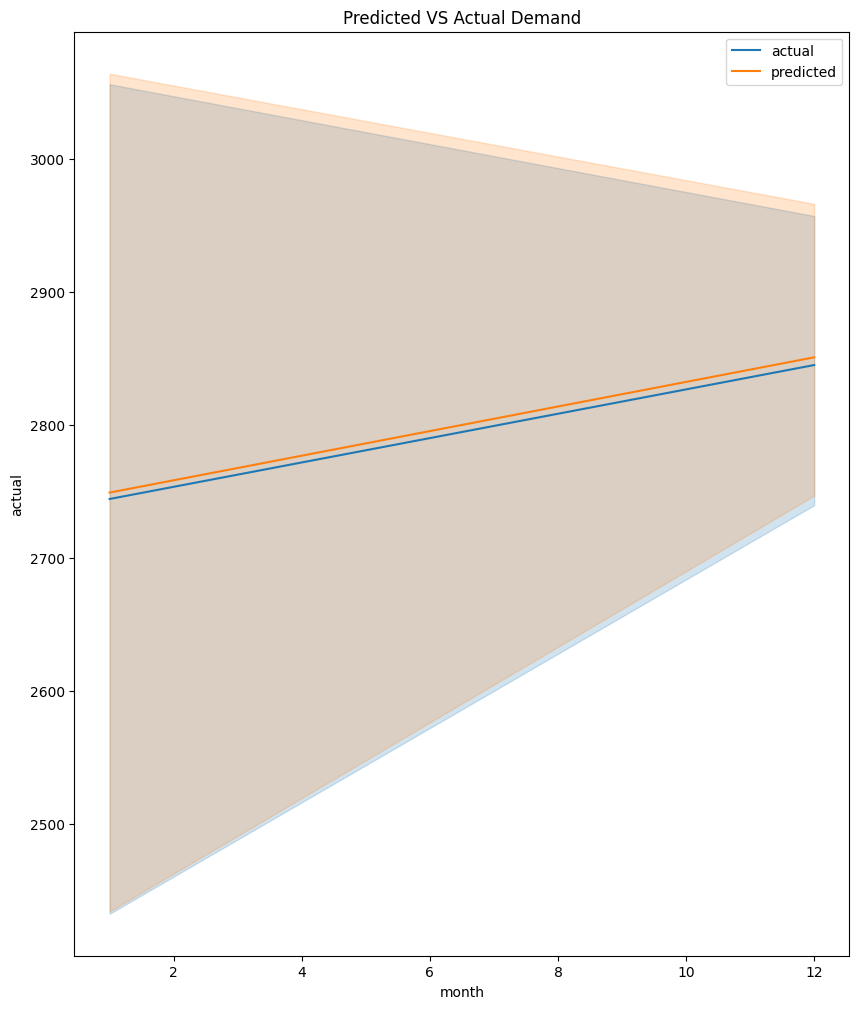

In [58]:
plt.figure(figsize = (10,12))
sns.lineplot(data = result,
             x = "month",
             y = "actual",
             label = "actual")
sns.lineplot(data = result,
             x = "month",
             y = "predicted",
             label = "predicted")
plt.legend()
plt.title("Predicted VS Actual Demand")
plt.show()
             

C:\Users\H P\AppData\Local\Temp\ipykernel_18820\869537677.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


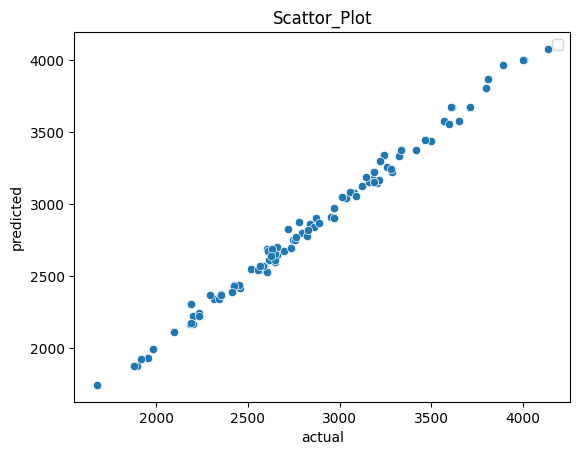

In [59]:
sns.scatterplot(data = result,
                x = "actual",
                y = "predicted")
plt.legend()
plt.title("Scattor_Plot")
plt.show()

In [60]:
plt.figure(figsize = (12, 5))
#plt.plot(y_test.values, label = "Actual")
sns.plot(data = result ()
plt.legend()
plt.show()

SyntaxError: '(' was never closed (1356347669.py, line 3)

In [61]:
xgb_ypred[:20]

array([3340.7212, 1997.6122, 3045.9766, 3678.379 , 3224.9902, 3042.4893,
       3178.1252, 2866.474 , 3262.2732, 3576.9246, 2347.334 , 3158.2722,
       2974.901 , 2226.823 , 3871.421 , 3080.7998, 2421.9888, 3057.883 ,
       2801.874 , 2597.7766], dtype=float32)

In [62]:
daily

,date,store_id,demand_forecast,units_ordered,product_id,category,region,inventory_level,units_sold,price,...,quarter,demand_lag1,demand_lag7,demand_30,demand_lag90,demand_roll3,units_sold_lag1,units_sold lag7,units_ordered_lag1,units_ordered_lag7
0,2022-04-01,S001,1982.36,2250,P0001,Furniture,West,4849,1879,58.6555,...,2,2834.98,3582.30,2762.67,2834.26,2568.430000,2723.0,3410.0,2192.0,2419.0
1,2022-04-01,S002,3000.36,2466,P0001,Groceries,South,5700,2928,58.3305,...,2,2992.81,2910.58,3199.86,3096.14,2807.133333,2868.0,2762.0,1976.0,2150.0
2,2022-04-01,S003,2681.10,2065,P0001,Clothing,North,5484,2527,59.4890,...,2,3324.21,2511.37,2041.04,3355.98,3019.910000,3241.0,2418.0,2430.0,2105.0
3,2022-04-01,S004,2922.02,2359,P0001,Electronics,South,5337,2792,45.1145,...,2,3099.17,2705.74,3257.77,2617.20,3112.530000,2936.0,2589.0,2140.0,2171.0
4,2022-04-01,S005,2944.63,2038,P0001,Furniture,North,5424,2750,52.1445,...,2,3355.22,3664.60,3456.82,3127.68,3239.570000,3209.0,3561.0,2279.0,2460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3200,2024-01-01,S001,2414.33,2566,P0001,Toys,East,5133,2278,47.8805,...,1,1918.47,3160.46,2960.33,3168.50,2071.566667,1855.0,3046.0,2201.0,1384.0
3201,2024-01-01,S002,2353.55,2430,P0001,Clothing,East,5594,2264,52.7360,...,1,2971.23,2450.19,2765.38,2649.43,2674.833333,2815.0,2340.0,2347.0,2505.0
3202,2024-01-01,S003,3185.65,2157,P0001,Clothing,West,5618,3067,54.9225,...,1,2187.29,2888.52,2497.37,2906.98,2734.180000,2203.0,2761.0,2085.0,2232.0
3203,2024-01-01,S004,2627.66,2173,P0001,Electronics,East,4410,2543,48.8420,...,1,2354.28,2197.79,2190.29,3011.94,2741.010000,2265.0,2102.0,1948.0,2602.0


FEATURE IMPORTANCE

In [63]:
importance = best_xgb_model.feature_importances_
importances = pd.DataFrame({"Feature":x_train.columns,
                            "Importance":importance})
importances = importances.sort_values(by = "Importance",ascending = False)
importances

,Feature,Importance
6,units_sold,0.967683
5,inventory_level,0.003162
25,units_ordered_lag7,0.002694
15,dayofweek,0.002494
19,demand_30,0.002472
12,seasonality,0.001754
9,weather_condition,0.001750
7,price,0.001549
18,demand_lag7,0.001461
23,units_sold lag7,0.001413


PERMUTATION IMPORTANCES

In [64]:
from sklearn.inspection import permutation_importance
permutation = permutation_importance(best_xgb_model,
                                     x_test,
                                     y_test,
                                     n_repeats = 10,
                                     random_state=42)
permutations = pd.DataFrame({"Feature":x_train.columns,
                             "Importance":permutation.importances_mean})
permutations = permutations.sort_values(by="Importance", ascending = False)
permutations


,Feature,Importance
6,units_sold,1.955256
17,demand_lag1,0.000207
18,demand_lag7,0.000071
8,discount,0.000058
25,units_ordered_lag7,0.000053
19,demand_30,0.000051
1,units_ordered,0.000048
0,store_id,0.000034
12,seasonality,0.000029
9,weather_condition,0.000029


VISUALIZATION

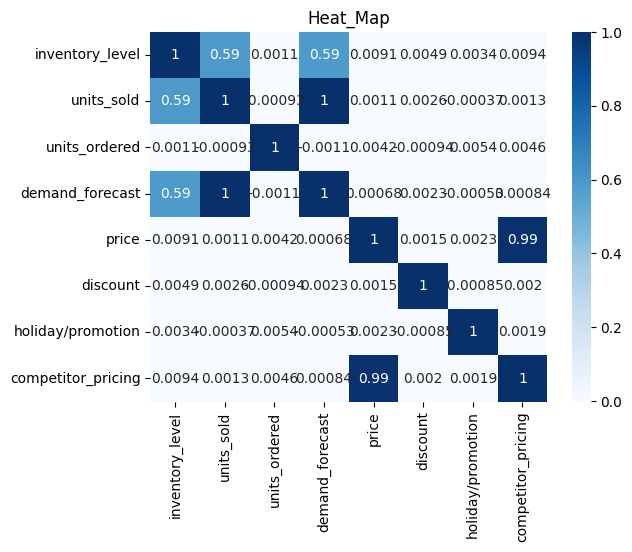

<Figure size 2000x2000 with 0 Axes>

In [65]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,
            annot = True,
            cmap = "Blues")
plt.title('Heat_Map')
plt.figure(figsize = (20, 20))
plt.show()

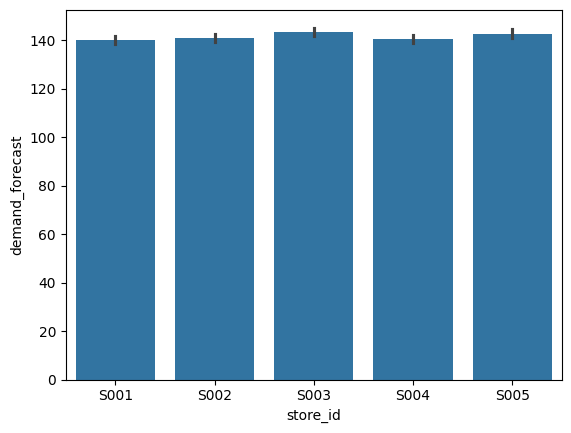

In [66]:
sns.barplot(data = df,
            x = "store_id",
            y = "demand_forecast")
plt.show()

PREDICTED VS FORECAST

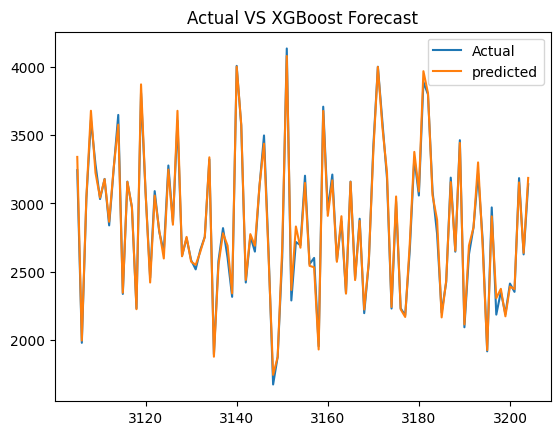

In [67]:
plt.plot(result["actual"], label = "Actual")
plt.plot(result["predicted"], label = "predicted")
plt.legend()
plt.title("Actual VS XGBoost Forecast")
plt.show()


FORECASTING

In [68]:
features = x_train.columns.tolist()
features

['store_id',
 'units_ordered',
 'product_id',
 'category',
 'region',
 'inventory_level',
 'units_sold',
 'price',
 'discount',
 'weather_condition',
 'holiday',
 'competitor_pricing',
 'seasonality',
 'year',
 'month',
 'dayofweek',
 'quarter',
 'demand_lag1',
 'demand_lag7',
 'demand_30',
 'demand_lag90',
 'demand_roll3',
 'units_sold_lag1',
 'units_sold lag7',
 'units_ordered_lag1',
 'units_ordered_lag7']

CREATE FUTURE DATES

In [69]:
daily["date"].min(), daily["date"].max()

(Timestamp('2022-04-01 00:00:00'), Timestamp('2024-01-01 00:00:00'))

In [70]:
future_dates = pd.date_range(
            start = "2024-01-02",
            periods = 5,
            freq = "D")
       
  

In [71]:
future_dates

DatetimeIndex(['2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05',
               '2024-01-06'],
              dtype='datetime64[ns]', freq='D')

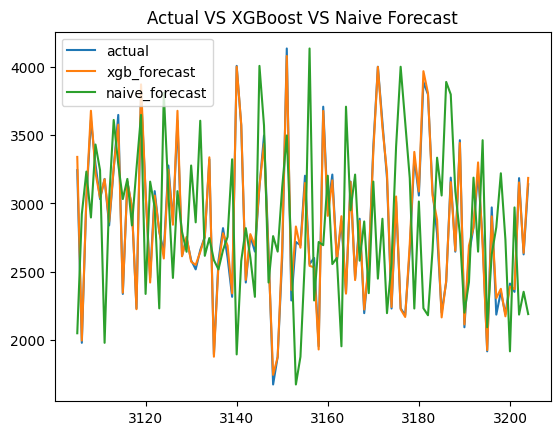

In [72]:
plt.plot(result["actual"], label = "actual")
plt.plot(result["predicted"], label = "xgb_forecast")
plt.plot(result["naive"], label = "naive_forecast")

plt.title("Actual VS XGBoost VS Naive Forecast")
plt.legend()
plt.show()

ERROR EVALUATION

In [73]:
result["error"] = result["actual"] - result["predicted"]

In [74]:
result

,store_id,units_ordered,product_id,category,region,inventory_level,units_sold,price,discount,weather_condition,...,demand_lag90,demand_roll3,units_sold_lag1,units_sold lag7,units_ordered_lag1,units_ordered_lag7,actual,predicted,naive,error
3105,S001,1711,P0001,Clothing,North,6351,3222,42.8565,10.25,Rainy,...,2795.96,2729.750000,2026.0,2899.0,1874.0,2448.0,3243.91,3340.721191,2050.74,-96.811191
3106,S002,2536,P0001,Groceries,South,5119,1876,48.5210,11.00,Snowy,...,2891.04,2341.223333,2851.0,2630.0,2413.0,2374.0,1980.66,1997.612183,2922.31,-16.952183
3107,S003,1855,P0001,Furniture,South,5670,2929,63.0135,10.00,Sunny,...,2315.95,2927.143333,3095.0,1955.0,1965.0,2027.0,3034.28,3045.976562,3233.43,-11.696563
3108,S004,2240,P0001,Electronics,East,5451,3590,55.1595,8.50,Snowy,...,3009.23,2569.073333,2744.0,3446.0,2361.0,2808.0,3611.24,3678.378906,2897.59,-67.138906
3109,S005,2326,P0001,Toys,West,5580,3119,47.5595,9.75,Snowy,...,3082.30,2801.253333,3352.0,3264.0,2313.0,2035.0,3286.55,3224.990234,3431.44,61.559766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3200,S001,2566,P0001,Toys,East,5133,2278,47.8805,8.50,Rainy,...,3168.50,2071.566667,1855.0,3046.0,2201.0,1384.0,2414.33,2392.948730,1918.47,21.381270
3201,S002,2430,P0001,Clothing,East,5594,2264,52.7360,10.50,Snowy,...,2649.43,2674.833333,2815.0,2340.0,2347.0,2505.0,2353.55,2373.453613,2971.23,-19.903613
3202,S003,2157,P0001,Clothing,West,5618,3067,54.9225,10.75,Sunny,...,2906.98,2734.180000,2203.0,2761.0,2085.0,2232.0,3185.65,3154.003662,2187.29,31.646338
3203,S004,2173,P0001,Electronics,East,4410,2543,48.8420,11.50,Snowy,...,3011.94,2741.010000,2265.0,2102.0,1948.0,2602.0,2627.66,2639.186768,2354.28,-11.526768


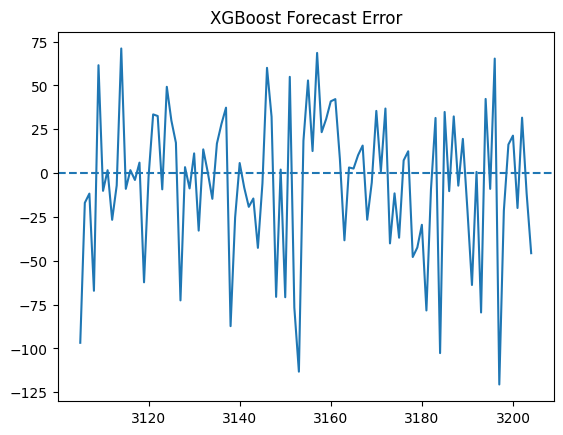

In [75]:
plt.plot(result["error"])
plt.axhline(0, linestyle = "--")
plt.title("XGBoost Forecast Error")
plt.show()

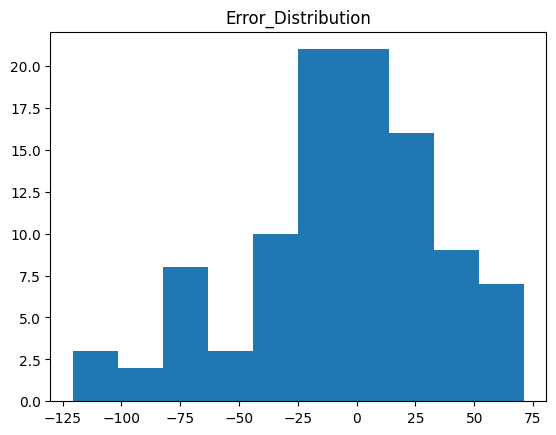

In [76]:
plt.hist(result["error"])
plt.title("Error_Distribution")
plt.show()

PLOT FEATURE IMPORTANCE

In [77]:
from xgboost import plot_importance

<Figure size 1000x700 with 0 Axes>

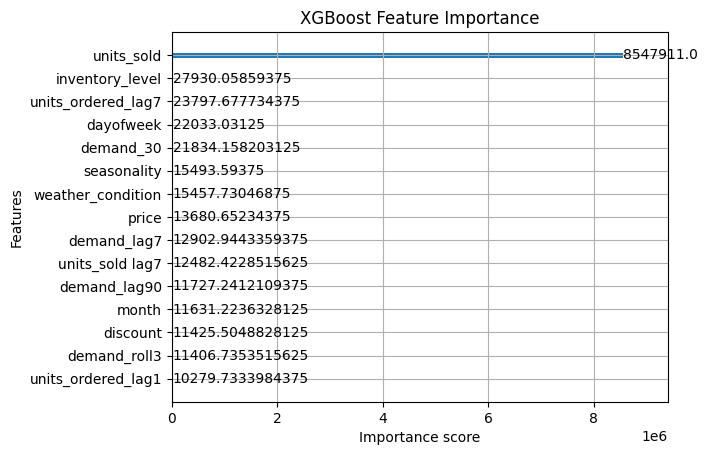

In [78]:
plt.figure(figsize = (10,7))
plot_importance(
    best_xgb_model,
    importance_type = "gain",
    max_num_features = 15)

plt.title("XGBoost Feature Importance")
plt.show()

INSTALL SHAP

In [79]:
!pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import shap

C:\Users\H P\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [81]:
explainer = shap.TreeExplainer(best_xgb_model)

In [83]:
shap_values = explainer.shap_values(x_test)

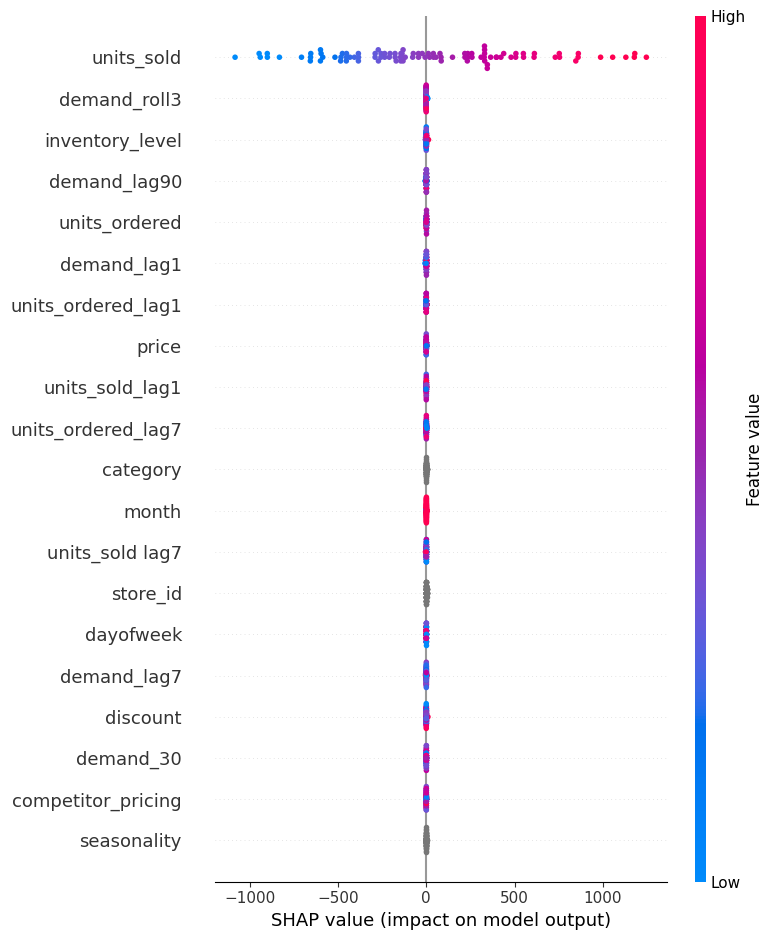

In [84]:
shap.summary_plot(shap_values,
                  x_test)

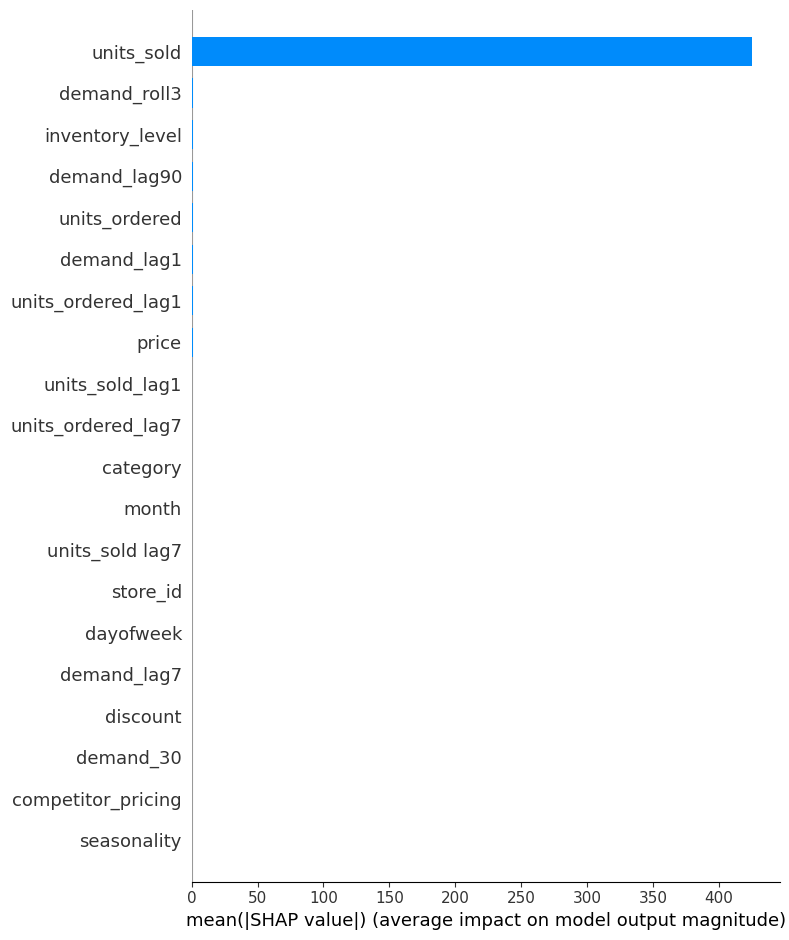

In [85]:
shap.summary_plot(shap_values,
                  x_test,
                  plot_type = "bar")


WALK FORWARD FORECASTING

In [86]:
daily

,date,store_id,demand_forecast,units_ordered,product_id,category,region,inventory_level,units_sold,price,...,quarter,demand_lag1,demand_lag7,demand_30,demand_lag90,demand_roll3,units_sold_lag1,units_sold lag7,units_ordered_lag1,units_ordered_lag7
0,2022-04-01,S001,1982.36,2250,P0001,Furniture,West,4849,1879,58.6555,...,2,2834.98,3582.30,2762.67,2834.26,2568.430000,2723.0,3410.0,2192.0,2419.0
1,2022-04-01,S002,3000.36,2466,P0001,Groceries,South,5700,2928,58.3305,...,2,2992.81,2910.58,3199.86,3096.14,2807.133333,2868.0,2762.0,1976.0,2150.0
2,2022-04-01,S003,2681.10,2065,P0001,Clothing,North,5484,2527,59.4890,...,2,3324.21,2511.37,2041.04,3355.98,3019.910000,3241.0,2418.0,2430.0,2105.0
3,2022-04-01,S004,2922.02,2359,P0001,Electronics,South,5337,2792,45.1145,...,2,3099.17,2705.74,3257.77,2617.20,3112.530000,2936.0,2589.0,2140.0,2171.0
4,2022-04-01,S005,2944.63,2038,P0001,Furniture,North,5424,2750,52.1445,...,2,3355.22,3664.60,3456.82,3127.68,3239.570000,3209.0,3561.0,2279.0,2460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3200,2024-01-01,S001,2414.33,2566,P0001,Toys,East,5133,2278,47.8805,...,1,1918.47,3160.46,2960.33,3168.50,2071.566667,1855.0,3046.0,2201.0,1384.0
3201,2024-01-01,S002,2353.55,2430,P0001,Clothing,East,5594,2264,52.7360,...,1,2971.23,2450.19,2765.38,2649.43,2674.833333,2815.0,2340.0,2347.0,2505.0
3202,2024-01-01,S003,3185.65,2157,P0001,Clothing,West,5618,3067,54.9225,...,1,2187.29,2888.52,2497.37,2906.98,2734.180000,2203.0,2761.0,2085.0,2232.0
3203,2024-01-01,S004,2627.66,2173,P0001,Electronics,East,4410,2543,48.8420,...,1,2354.28,2197.79,2190.29,3011.94,2741.010000,2265.0,2102.0,1948.0,2602.0


In [87]:
daily = daily.sort_values(by = "date", ascending = True).reset_index(drop = True)

In [88]:
daily

,date,store_id,demand_forecast,units_ordered,product_id,category,region,inventory_level,units_sold,price,...,quarter,demand_lag1,demand_lag7,demand_30,demand_lag90,demand_roll3,units_sold_lag1,units_sold lag7,units_ordered_lag1,units_ordered_lag7
0,2022-04-01,S001,1982.36,2250,P0001,Furniture,West,4849,1879,58.6555,...,2,2834.98,3582.30,2762.67,2834.26,2568.430000,2723.0,3410.0,2192.0,2419.0
1,2022-04-01,S002,3000.36,2466,P0001,Groceries,South,5700,2928,58.3305,...,2,2992.81,2910.58,3199.86,3096.14,2807.133333,2868.0,2762.0,1976.0,2150.0
2,2022-04-01,S003,2681.10,2065,P0001,Clothing,North,5484,2527,59.4890,...,2,3324.21,2511.37,2041.04,3355.98,3019.910000,3241.0,2418.0,2430.0,2105.0
3,2022-04-01,S004,2922.02,2359,P0001,Electronics,South,5337,2792,45.1145,...,2,3099.17,2705.74,3257.77,2617.20,3112.530000,2936.0,2589.0,2140.0,2171.0
4,2022-04-01,S005,2944.63,2038,P0001,Furniture,North,5424,2750,52.1445,...,2,3355.22,3664.60,3456.82,3127.68,3239.570000,3209.0,3561.0,2279.0,2460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3200,2024-01-01,S003,3185.65,2157,P0001,Clothing,West,5618,3067,54.9225,...,1,2187.29,2888.52,2497.37,2906.98,2734.180000,2203.0,2761.0,2085.0,2232.0
3201,2024-01-01,S004,2627.66,2173,P0001,Electronics,East,4410,2543,48.8420,...,1,2354.28,2197.79,2190.29,3011.94,2741.010000,2265.0,2102.0,1948.0,2602.0
3202,2024-01-01,S001,2414.33,2566,P0001,Toys,East,5133,2278,47.8805,...,1,1918.47,3160.46,2960.33,3168.50,2071.566667,1855.0,3046.0,2201.0,1384.0
3203,2024-01-01,S002,2353.55,2430,P0001,Clothing,East,5594,2264,52.7360,...,1,2971.23,2450.19,2765.38,2649.43,2674.833333,2815.0,2340.0,2347.0,2505.0


CREATE SIMPLE WALK FOWARD SPLIT

In [89]:
initial_train_size = int(len(X) * 0.8)
initial_train_size

2564

In [90]:
X_train = X.iloc[:initial_train_size]
Y_train = Y.iloc[:initial_train_size]

X_test = X.iloc[initial_train_size:initial_train_size + 1]
Y_test = Y.iloc[initial_train_size:initial_train_size + 1]

TRAIN XGBOOST FORECAST

In [236]:
#walk_model = XGBRegressor(random_state = 42)

In [237]:
#predictions = []
#actuals1 = []

#params1 = {"n_estimators":[100,300,500],
          #"max_depth":[3,5,7],
          #"learning_rate":[0.01, 0.1, 0.5],
         # "subsample":[0.1, 0.5,0.8]}
                           

In [239]:
#tscv1 = TimeSeriesSplit(n_splits=5)

In [240]:
#grid1= GridSearchCV(estimator = walk_model,
                    param_grid=params1,
                    cv = tscv1,
                    scoring = "neg_mean_squared_error")

In [241]:
#grid1.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 300, ...], 'subsample': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versioncha

In [242]:
#grid1.best_params_

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}

In [243]:
#best_walk_model = grid1.best_estimator_

In [95]:
predictions = []
actuals1 = []


for i in range(initial_train_size, len(X)):
    X_train = X.iloc[:i]
    Y_train = Y.iloc[:i]

    X_test = X.iloc[i:i + 1]
    Y_test = Y.iloc[i:i + 1]

    walk_model = XGBRegressor(random_state = 42,
                             learning_rate = 0.1,
                              max_depth = 3, 
                              n_estimators = 100, 
                              subsample =  0.8)
    walk_model.fit(X_train, Y_train)
    
    walk_ypred = walk_model.predict(X_test)[0]

    predictions.append(walk_ypred)
    actuals1.append(Y_test.iloc[0])
     
  

In [97]:
len(predictions)

641

In [100]:
len(actuals1)

641

WALK MODEL EVALUATION

In [102]:
r2 = r2_score(actuals1, predictions)
r2

0.9919768093516718

In [103]:
mae = mean_absolute_error(actuals1, predictions)
mae

34.9345427752657

In [105]:
mse = mean_squared_error(actuals1,predictions)
mse

1959.8923805800848

In [106]:
rmse = np.sqrt(mse)
rmse

np.float64(44.27067178821759)

In [107]:
X.columns.tolist()

['store_id',
 'units_ordered',
 'product_id',
 'category',
 'region',
 'inventory_level',
 'units_sold',
 'price',
 'discount',
 'weather_condition',
 'holiday',
 'competitor_pricing',
 'seasonality',
 'year',
 'month',
 'dayofweek',
 'quarter',
 'demand_lag1',
 'demand_lag7',
 'demand_30',
 'demand_lag90',
 'demand_roll3',
 'units_sold_lag1',
 'units_sold lag7',
 'units_ordered_lag1',
 'units_ordered_lag7']

In [109]:
last_row = daily.iloc[-1]
last_row

date                  2024-01-01 00:00:00
store_id                             S005
demand_forecast                   3141.31
units_ordered                        1908
product_id                          P0001
category                             Toys
region                              North
inventory_level                      5721
units_sold                           3092
price                             61.9995
discount                              7.5
weather_condition                  Cloudy
holiday                                 1
competitor_pricing                62.2655
seasonality                        Winter
year                                 2024
month                                   1
dayofweek                               0
quarter                                 1
demand_lag1                       2190.99
demand_lag7                       2564.33
demand_30                         3246.44
demand_lag90                      2112.32
demand_roll3                  2796

In [110]:
daily["date"].tail()

3200   2024-01-01
3201   2024-01-01
3202   2024-01-01
3203   2024-01-01
3204   2024-01-01
Name: date, dtype: datetime64[ns]

In [111]:
daily["date"].min(), daily["date"].max()

(Timestamp('2022-04-01 00:00:00'), Timestamp('2024-01-01 00:00:00'))

In [112]:
daily["date"].nunique()

641

In [114]:
daily.groupby("date").size().head(50)

date
2022-04-01    5
2022-04-02    5
2022-04-03    5
2022-04-04    5
2022-04-05    5
2022-04-06    5
2022-04-07    5
2022-04-08    5
2022-04-09    5
2022-04-10    5
2022-04-11    5
2022-04-12    5
2022-04-13    5
2022-04-14    5
2022-04-15    5
2022-04-16    5
2022-04-17    5
2022-04-18    5
2022-04-19    5
2022-04-20    5
2022-04-21    5
2022-04-22    5
2022-04-23    5
2022-04-24    5
2022-04-25    5
2022-04-26    5
2022-04-27    5
2022-04-28    5
2022-04-29    5
2022-04-30    5
2022-05-01    5
2022-05-02    5
2022-05-03    5
2022-05-04    5
2022-05-05    5
2022-05-06    5
2022-05-07    5
2022-05-08    5
2022-05-09    5
2022-05-10    5
2022-05-11    5
2022-05-12    5
2022-05-13    5
2022-05-14    5
2022-05-15    5
2022-05-16    5
2022-05-17    5
2022-05-18    5
2022-05-19    5
2022-05-20    5
dtype: int64

In [116]:
Y.name

'demand_forecast'

In [117]:
X.shape

(3205, 26)

In [118]:
Y.shape

(3205,)

In [121]:
X_last = X.iloc[[-1]].copy()
X_last.T

,3204
store_id,S005
units_ordered,1908
product_id,P0001
category,Toys
region,North
inventory_level,5721
units_sold,3092
price,61.9995
discount,7.5
weather_condition,Cloudy


In [122]:
X.columns.tolist()

['store_id',
 'units_ordered',
 'product_id',
 'category',
 'region',
 'inventory_level',
 'units_sold',
 'price',
 'discount',
 'weather_condition',
 'holiday',
 'competitor_pricing',
 'seasonality',
 'year',
 'month',
 'dayofweek',
 'quarter',
 'demand_lag1',
 'demand_lag7',
 'demand_30',
 'demand_lag90',
 'demand_roll3',
 'units_sold_lag1',
 'units_sold lag7',
 'units_ordered_lag1',
 'units_ordered_lag7']

In [124]:
type(best_xgb_model)

xgboost.sklearn.XGBRegressor

In [126]:
test_date = daily.loc[daily["date"] > time_split, "date"]

In [138]:
import matplotlib.dates as mdates

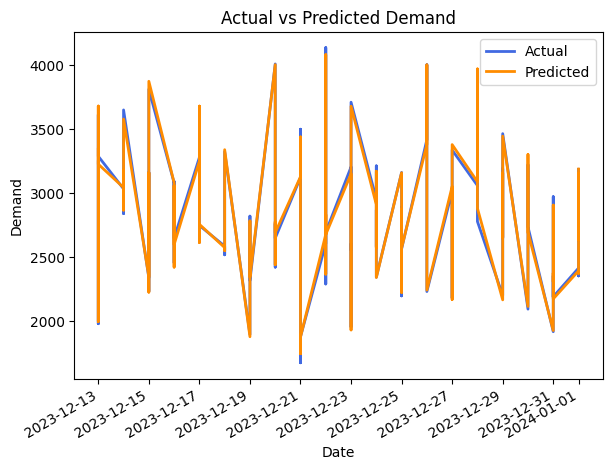

In [149]:
plt.plot(test_date, y_test.values, label = "Actual", linewidth = 2, color = "royalblue")
plt.plot(test_date, xgb_ypred, label = "Predicted", linewidth = 2, color = "darkorange")

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Actual vs Predicted Demand")
plt.legend()
#plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
#plt.figure(figsize = (20,20))
#locator = mdates.AutoDateLocator()
#plt.gca().xaxis.set_major_locator(locator)
#plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
plt.tight_layout()
plt.gcf().autofmt_xdate()
#plt.xticks(test_date.iloc[::30],
          # rotation = 45)
plt.show()